# Phase 4 — Testing

Run this notebook to test the Mamdani fuzzy controller on 12 useful input combinations and save the output chart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

def build_controller():
    power = ctrl.Antecedent(np.arange(0, 101, 1), 'power')
    flow = ctrl.Antecedent(np.arange(0, 21, 1), 'flow')
    temp = ctrl.Antecedent(np.arange(20, 81, 1), 'temp')
    pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'pressure')
    rate = ctrl.Consequent(np.arange(0, 10.01, 0.01), 'rate')
    
    for variable, terms in [
        (power, {'low': [0, 0, 50], 'medium': [25, 50, 75], 'high': [50, 100, 100]}),
        (flow, {'low': [0, 0, 10], 'medium': [5, 10, 15], 'high': [10, 20, 20]}),
        (pressure, {'low': [0, 0, 50], 'medium': [25, 50, 75], 'high': [50, 100, 100]}),
        (temp, {'low': [20, 20, 40], 'normal': [30, 50, 70], 'high': [60, 80, 80]}),
    ]:
        for label, points in terms.items():
            variable[label] = fuzz.trimf(variable.universe, points)
    for label, points in {'off': [0, 0, 2], 'low': [1, 3, 5], 'medium': [4, 6, 8], 'high': [7, 10, 10]}.items():
        rate[label] = fuzz.trimf(rate.universe, points)
    rules = [
        ctrl.Rule(power['high'] & flow['high'] & pressure['low'] & temp['normal'], rate['high']),
        ctrl.Rule(power['high'] & flow['low'] & pressure['low'] & temp['normal'], rate['medium']),
        ctrl.Rule(power['medium'] & flow['medium'] & pressure['low'] & temp['normal'], rate['medium']),
        ctrl.Rule(power['medium'] & flow['low'] & pressure['low'] & temp['normal'], rate['medium']),
        ctrl.Rule(power['low'] & flow['high'] & pressure['low'] & temp['normal'], rate['medium']),
        ctrl.Rule(power['low'] & flow['medium'] & pressure['low'] & temp['normal'], rate['low']),
        ctrl.Rule(power['low'] & flow['low'] & pressure['low'] & temp['normal'], rate['low']),
        ctrl.Rule(power['high'] & flow['high'] & pressure['medium'] & temp['normal'], rate['high']),
        ctrl.Rule(power['high'] & flow['medium'] & pressure['medium'] & temp['normal'], rate['medium']),
        ctrl.Rule(power['low'] & flow['low'] & pressure['high'] & temp['normal'], rate['off']),
        ctrl.Rule(power['medium'] & temp['high'], rate['low']),
    ]
    return ctrl.ControlSystem(rules)

controller = build_controller()

def evaluate(power, flow, temp, pressure):
    sim = ctrl.ControlSystemSimulation(controller)
    sim.input['power'] = power
    sim.input['flow'] = flow
    sim.input['temp'] = temp
    sim.input['pressure'] = pressure
    sim.compute()
    return float(sim.output['rate'])


,Case,Power (kW),Water flow (L/min),Stack temp (°C),Tank pressure (bar),Hydrogen rate (kg/h),Result
0,T01 Nominal operation,70,14,50,35,7.59,Medium
1,T02 Very low renewable power,5,2,50,20,3.00,Low
2,T03 Low renewable power,20,10,50,35,3.00,Low
3,T04 Medium balanced operation,50,10,50,35,6.00,Medium
4,T05 High renewable availability,85,18,50,25,8.83,High
5,T06 High-pressure protection,15,3,50,85,0.71,Off / protection
6,T07 Medium tank pressure,70,14,50,70,7.10,Medium
7,T08 Low water flow,80,2,50,35,6.00,Medium
8,T09 High-temperature derating,60,10,75,35,3.00,Low
9,T10 Cool stack near lower band,60,14,35,35,7.10,Medium


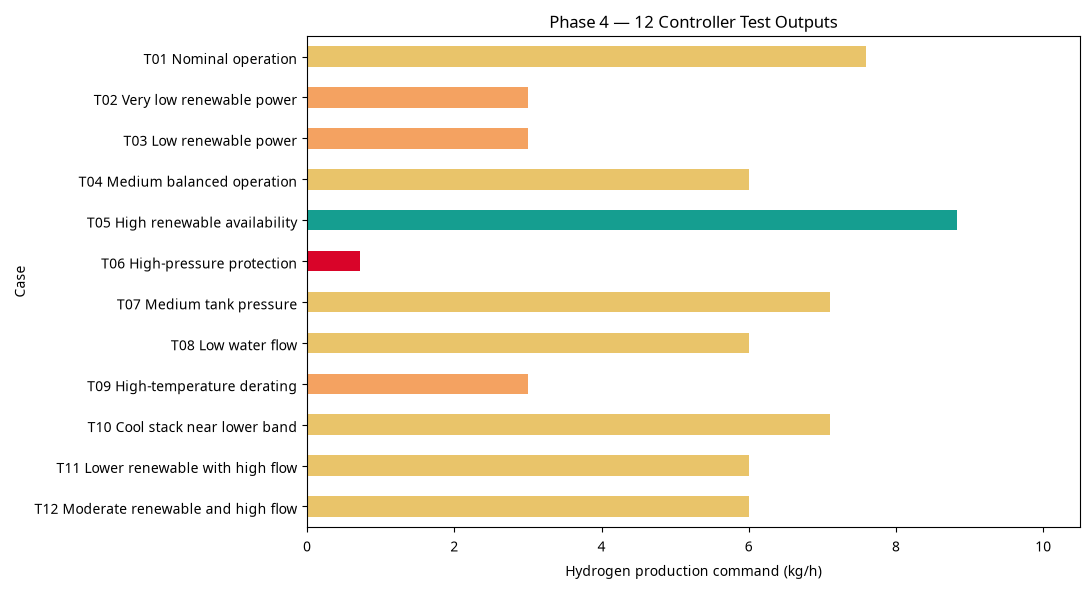

In [2]:
# 12 deterministic controller tests
tests = pd.DataFrame([
    ('T01 Nominal operation', 70, 14, 50, 35),
    ('T02 Very low renewable power', 5, 2, 50, 20),
    ('T03 Low renewable power', 20, 10, 50, 35),
    ('T04 Medium balanced operation', 50, 10, 50, 35),
    ('T05 High renewable availability', 85, 18, 50, 25),
    ('T06 High-pressure protection', 15, 3, 50, 85),
    ('T07 Medium tank pressure', 70, 14, 50, 70),
    ('T08 Low water flow', 80, 2, 50, 35),
    ('T09 High-temperature derating', 60, 10, 75, 35),
    ('T10 Cool stack near lower band', 60, 14, 35, 35),
    ('T11 Lower renewable with high flow', 35, 16, 50, 20),
    ('T12 Moderate renewable and high flow', 35, 18, 50, 35),
], columns=['Case', 'Power (kW)', 'Water flow (L/min)', 'Stack temp (°C)', 'Tank pressure (bar)'])

tests['Hydrogen rate (kg/h)'] = tests.apply(lambda r: evaluate(r['Power (kW)'], r['Water flow (L/min)'], r['Stack temp (°C)'], r['Tank pressure (bar)']), axis=1)
tests['Result'] = pd.cut(tests['Hydrogen rate (kg/h)'], [-0.01, 2, 5, 8, 10.1], labels=['Off / protection', 'Low', 'Medium', 'High'])
display(tests.style.format({'Hydrogen rate (kg/h)': '{:.2f}'}))

colors = tests['Result'].map({'Off / protection': '#d90429', 'Low': '#f4a261', 'Medium': '#e9c46a', 'High': '#159e90'})
ax = tests.plot.barh(x='Case', y='Hydrogen rate (kg/h)', color=colors, legend=False, figsize=(11, 6))
ax.set(xlim=(0, 10.5), xlabel='Hydrogen production command (kg/h)', title='Phase 4 — 12 Controller Test Outputs')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('phase4_test_outputs.png', dpi=160)
plt.show()
tests.to_csv('phase4_test_results.csv', index=False)
